In [30]:
import matplotlib.pyplot as plt
import numpy as np

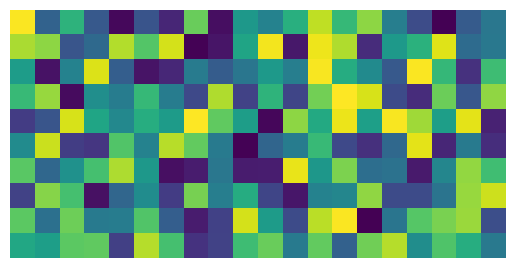

In [31]:
rand_array= np.random.rand(10,20)
plt.imshow(rand_array)
plt.axis('off')
plt.show()

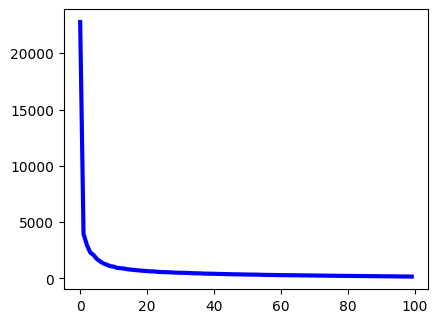

In [32]:
from PIL import Image
img= Image.open('img.jpeg').convert('L')
##convert to grayscale

A= np.array(img, dtype=float)
og_shape= A.shape

eigenval, V= np.linalg.eigh(A.T@A)

idx= np.argsort(eigenval)[::-1]
eigenval= eigenval[idx]
V= V[:,idx]

sigma= np.sqrt(np.maximum(eigenval,0))

##u = m*k
U= np.zeros((A.shape[0],V.shape[1]))
for i in range(len(sigma)):
    if sigma[i]>1e-9:
        U[:,i]= (A@V[:,i])/sigma[i]


plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.plot(sigma[:100], color='blue', lw=3)
plt.show()

In [33]:
plt.figure(figsize=(160,80))
k_values= [5,20,50,100]
for i, k in enumerate(k_values):
    A_k= U[:,:k]@(np.diag(sigma[:k]))@V[:,:k].T

    og_size= A.size
    comp_size= k*(A.shape[1]+1+A.shape[0])
    ratio= og_size/comp_size

    plt.subplot(2,3,i+1)
    plt.title("rank k= {k}")
    plt.imshow(A_k, cmap="viridis")

plt.show()